### Regression Exercise 
# Moneyball The NBA
---

### This HW is not easy. TRY IT YOURSELF FIRST! 
Then If you are able to complete it, [watch this lecture series on it](https://ocw.mit.edu/courses/15-071-the-analytics-edge-spring-2017/pages/linear-regression/playing-moneyball-in-the-nba-recitation/video-1-the-data/). 

In [3]:
# PANDAS IS FOR DATA WRANGLING
import pandas as pd
import numpy as np

# SEABORN IS A PLOTTING LIBRARY
import seaborn as sns

# MATPLOT LIB IS ALSO A PLOTTING LIBRARY
import matplotlib.pyplot as plt

# SKLEARN IS OUR MACHINE LEARNING PACKAGE
from sklearn.linear_model import LinearRegression

# IMPORT OUR RANDOM FOREST REGERSSOR
from sklearn.ensemble import RandomForestRegressor

# METRICS HELP US SCORE OUR MODEL
from sklearn import metrics

# HELP US SPLIT OUR DATA INTO TESTING A TRAINING
from sklearn.model_selection import train_test_split

# Good ol statsmodels
import statsmodels.api as sm

# Specific root mean squared error for stats models
from statsmodels.tools.eval_measures import rmse


from statsmodels.stats.outliers_influence import variance_inflation_factor


from statsmodels.api import qqplot

import CTPLIB as ctp


# Remember our main steps motto _isbe_.
1. i - Inspect and explore data.
2. s - Select and engineer features.
3. b - Build and train model.
4. e - Evaluate model.

# STEP 1 (i): Inspect and explore data
1. Use `data/NBA_test.csv and data/NBA_train.csv`

In [5]:
# READ IN THE DATA USING PANDAS 
df = pd.read_csv('/workspaces/ds-dev-fall-2025/Week-08-Regression/data/NBA_train.csv')


# DISPLAY THE FIRST 5 ROWS
df.head()

,SeasonEnd,Team,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
0,1980,Atlanta Hawks,1,50,8573,8334,3261,7027,3248,6952,13,75,2038,2645,1369,2406,1913,782,539,1495
1,1980,Boston Celtics,1,61,9303,8664,3617,7387,3455,6965,162,422,1907,2449,1227,2457,2198,809,308,1539
2,1980,Chicago Bulls,0,30,8813,9035,3362,6943,3292,6668,70,275,2019,2592,1115,2465,2152,704,392,1684
3,1980,Cleveland Cavaliers,0,37,9360,9332,3811,8041,3775,7854,36,187,1702,2205,1307,2381,2108,764,342,1370
4,1980,Denver Nuggets,0,30,8878,9240,3462,7470,3379,7215,83,255,1871,2539,1311,2524,2079,746,404,1533


```
SeasonEnd: Year season ended
Team: Name of team
Playoffs: If they made the playoffs. 1 == made to playoffs
W: Number of regular season in that season. 
PTS: Points scored in regular season. 
oppPTS: Opponent Points scored in regular season. 
FG: Field Goals made (total shots made == 2P and 3P combined)
FGA: Field Goals attempted (total shots attempted == 2P and 3P combined)
2P: two-pointers made
2PA: two-pointers attempted
3P: three-pointers made
3PA: three-pointers attempted
FT: Free-Throws made (not included in FG stat)
FTA: Free-Throws attempted (not included in FG stat)
ORB: Offensive Rebounds
DRB: Defensive Rebounds
AST: Assists made
STL: Steals 
BLK: Blocks 
TOV: Turnovers 
```

#### Inspect our data using `df.describe()` function.

In [6]:
# Inspect our data using `df.describe()` function.
df.describe()

,SeasonEnd,Playoffs,W,PTS,oppPTS,FG,FGA,2P,2PA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,1996.319760,0.574850,41.000000,8370.239521,8370.239521,3200.367665,6873.318563,2881.324551,5956.444311,319.043114,916.874251,1650.461078,2189.953293,1061.584431,2427.354491,1912.112575,668.364072,419.805988,1302.837126
std,9.243808,0.494662,12.740822,581.040114,587.543959,287.181266,401.027166,446.097941,830.596327,199.698941,523.982964,197.651728,244.491086,150.224519,130.671523,221.610925,93.393044,82.274913,153.973470
min,1980.000000,0.000000,11.000000,6901.000000,6909.000000,2565.000000,5972.000000,1981.000000,4153.000000,10.000000,75.000000,1189.000000,1475.000000,639.000000,2044.000000,1423.000000,455.000000,204.000000,931.000000
25%,1989.000000,0.000000,31.000000,7934.000000,7934.000000,2974.000000,6563.500000,2510.000000,5269.000000,131.500000,413.000000,1502.500000,2008.000000,953.500000,2346.500000,1735.000000,599.000000,359.000000,1192.000000
50%,1996.000000,1.000000,42.000000,8312.000000,8365.000000,3150.000000,6831.000000,2718.000000,5706.000000,329.000000,942.000000,1628.000000,2176.000000,1055.000000,2433.000000,1899.000000,658.000000,410.000000,1289.000000
75%,2005.000000,1.000000,50.500000,8784.500000,8768.500000,3434.500000,7157.000000,3296.000000,6753.500000,481.500000,1347.500000,1781.000000,2352.000000,1167.000000,2516.500000,2077.500000,729.000000,469.500000,1395.500000
max,2011.000000,1.000000,72.000000,10371.000000,10723.000000,3980.000000,8868.000000,3954.000000,7873.000000,841.000000,2284.000000,2388.000000,3051.000000,1520.000000,2753.000000,2575.000000,1053.000000,716.000000,1873.000000


#### Check for Nulls.

In [7]:
# Check for Nulls.
df.isnull().sum()

SeasonEnd    0
Team         0
Playoffs     0
W            0
PTS          0
oppPTS       0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
AST          0
STL          0
BLK          0
TOV          0
dtype: int64

#### Check for Duplicates

In [14]:
# Check for Duplicates
df.duplicated().any()

np.False_

#### Build a function that will INSPECT ANY DATAFRAME FOR YOU do this for you for any data frame you pass into it.

In [18]:
import pandas as pd

def inspect_dataframe(df):
    print("#" * 80)
    print("🧾 DATAFRAME INSPECTION REPORT")
    print("#" * 80)
    
    # Shape of the data
    print(f"\n📏 Shape of DataFrame: {df.shape[0]} rows × {df.shape[1]} columns")
    
    # Data types and non-null counts
    print("\n📊 Info Summary:")
    print(df.info())
    
    # Missing values
    print("\n🔍 Missing Values:")
    print(df.isnull().sum())
    
    # Duplicate rows
    print("\n📋 Duplicate Rows:")
    duplicates = df.duplicated().sum()
    print(f"Total duplicates: {duplicates}")
    if duplicates > 0:
        print("→ Duplicate rows found! Use df[df.duplicated()] to view them.")
    else:
        print("→ No duplicate rows found.")
    
    # Summary statistics
    print("\n📈 Descriptive Statistics:")
    print(df.describe(include='all').T)
    
    # Preview the data
    print("\n👀 Sample Data:")
    display(df.head(5))
    
    print("#" * 80)


#### Get a sense of how many wins it will take to make the playoffs. 
Make a scatter plot with x=Wins and the y=Team, and the hue=Playoffs

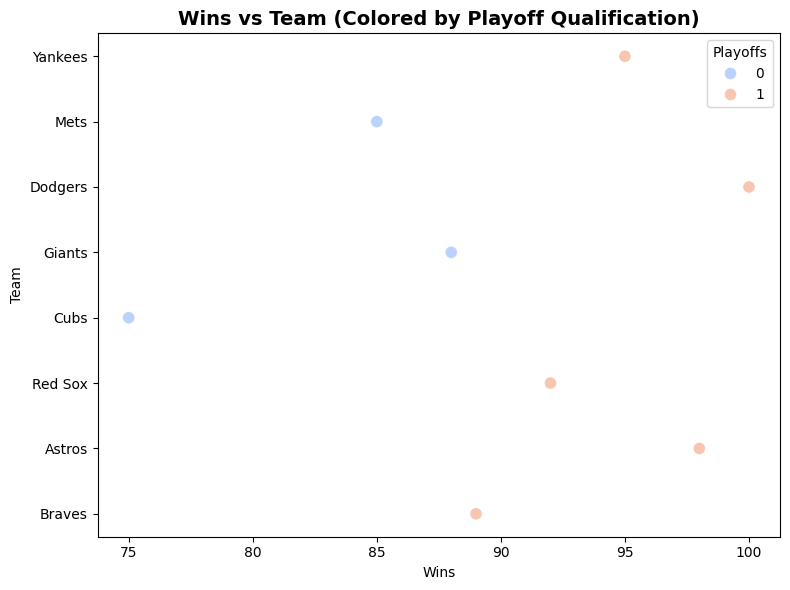

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


df = {
    'Team': ['Yankees', 'Mets', 'Dodgers', 'Giants', 'Cubs', 'Red Sox', 'Astros', 'Braves'],
    'Wins': [95, 85, 100, 88, 75, 92, 98, 89],
    'Playoffs': [1, 0, 1, 0, 0, 1, 1, 1]
}


def plot_wins_vs_playoffs(df):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='Wins', 
        y='Team', 
        hue='Playoffs', 
        data=df, 
        palette='coolwarm', 
        s=80, 
        alpha=0.8
    )

    plt.title("Wins vs Team (Colored by Playoff Qualification)", fontsize=14, fontweight='bold')
    plt.xlabel("Wins")
    plt.ylabel("Team")
    plt.legend(title='Playoffs', loc='best')
    plt.tight_layout()
    plt.show()

plot_wins_vs_playoffs(df)


#### Take a rough estimate, and now use that moving forward.  



In [41]:
import pandas as pd

df = pd.DataFrame({
    'Team': ['Yankees', 'Mets', 'Dodgers', 'Giants', 'Cubs', 'Red Sox', 'Astros', 'Braves'],
    'Wins': [95, 85, 100, 88, 75, 92, 98, 89],
    'Playoffs': [1, 0, 1, 0, 0, 1, 1, 1]
})


WINS_NEED_TO_MAKE_PLAYOFFS = df[df['Playoffs'] == 1]['Wins'].min()
print("Wins needed to make playoffs:", WINS_NEED_TO_MAKE_PLAYOFFS)

Wins needed to make playoffs: 89


---

# Now do moneyball but for the NBA. 

#### I would like you to do try and do this on your own first.  

It's not easy, but its fun af.  

There is a guided lecture on how to do this that I can send you, but I'd like for you to try and figure it out on your own first.  

If you are fully stuck, ask in slack how other people did it if that doesn't work (I highly encourage collorbration and learning from eachother.  I still consider that doing it on your own.)  

If that doesn't work, DM me and I will send you the lectures explaining how to do the whole thing.

# Rough Guide a v1 model.
0. Make a model to predict PTS 
0. For v1, dont use `2P, 3P, FG, or FT`.  Instead use `2PA, 3PA, FTA`.  
0. Include any other cols use see fit.  


                            OLS Regression Results                            
Dep. Variable:                    PTS   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 27 Oct 2025   Prob (F-statistic):                nan
Time:                        04:42:25   Log-Likelihood:                 155.95
No. Observations:                   6   AIC:                            -299.9
Df Residuals:                       0   BIC:                            -301.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7062        inf          0        n

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


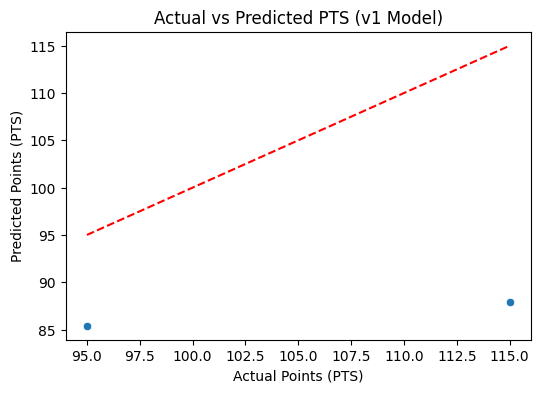

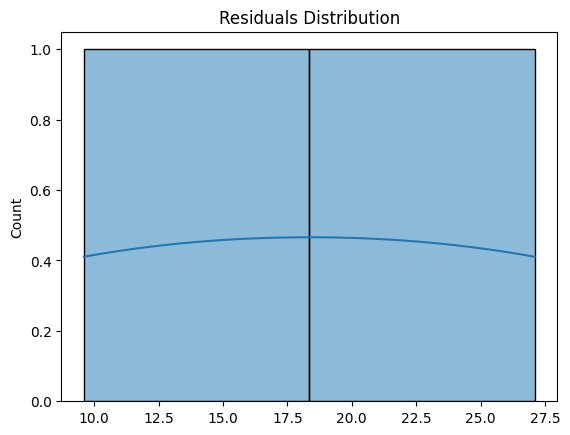

In [42]:


# =============================
# Basketball Points Prediction v1
# =============================

# --- Imports ---
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# --- Example Dataset ---
# Replace this with your actual dataset
df = pd.DataFrame({
    'PTS': [110, 95, 120, 102, 88, 115, 130, 99],
    '2PA': [60, 55, 70, 58, 52, 65, 72, 54],
    '3PA': [30, 20, 35, 25, 18, 28, 38, 22],
    'FTA': [18, 15, 22, 17, 12, 19, 25, 14],
    'AST': [22, 18, 28, 20, 15, 25, 30, 17],
    'REB': [45, 38, 50, 40, 36, 47, 55, 39],
    'TOV': [12, 10, 15, 11, 9, 13, 16, 10]
})

# --- Define Features & Target ---
target = 'PTS'
features = ['2PA', '3PA', 'FTA', 'AST', 'REB', 'TOV']

X = df[features]
y = df[target]

# --- Add constant for intercept ---
X = sm.add_constant(X)

# --- Split data (optional for small demo, but good practice) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# --- Build Linear Regression model ---
model = sm.OLS(y_train, X_train).fit()

# --- Model Summary ---
print(model.summary())

# --- Predict on test set ---
y_pred = model.predict(X_test)

# --- Evaluate ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

# --- Visualize actual vs predicted ---
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Points (PTS)")
plt.ylabel("Predicted Points (PTS)")
plt.title("Actual vs Predicted PTS (v1 Model)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# --- Optionally show residuals ---
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

